# Import

In [140]:
%pip install -q pandas seaborn matplotlib missingno statsmodels fastparquet

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import statsmodels.api as sm
import seaborn as sns 
import missingno as msno

# Constants

In [138]:
PATH = "../../data/df_ID_"
DATA_PATH =  "../../data/detection_fuite.csv" 
x = "valeur_active"

# Exploratory Data Analysis

In [3]:
def wrangle(path):
     
    df = pd.read_csv(DATA_PATH, parse_dates=["valeur_date"], index_col=["valeur_date"])

    #select from id_1 to id_20
    ids = [f"ID_{i}" for i in range(1, 21)]
    new_df = df[df["libelle"].isin(ids)]
    return new_df


In [4]:
df = pd.read_csv(DATA_PATH, parse_dates=["valeur_date"], index_col=["valeur_date"])
df.sample(10)

,valeur_active,libelle
valeur_date,,
2024-02-13,0.000000,ID_276
2024-06-19,NaN,ID_357
2024-03-03,0.000000,ID_90
2022-11-25,202.000000,ID_35
2024-03-04,49.000000,ID_81
2022-03-09,40.700001,ID_358
2023-07-16,25.430000,ID_350
2022-10-20,136.339996,ID_335
2023-08-30,4.600000,ID_444


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 470900 entries, 2019-01-01 to 2024-12-31
Data columns (total 2 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   valeur_active  448808 non-null  float64
 1   libelle        470900 non-null  object 
dtypes: float64(1), object(1)
memory usage: 10.8+ MB


In [6]:
df.describe()

,valeur_active
count,4.488080e+05
mean,1.160575e+03
std,3.013335e+05
min,-8.740000e+01
25%,7.972603e-01
50%,5.100000e+00
75%,2.000000e+01
max,9.999999e+07


## Extract measurements from ID_1 to ID_20

In [7]:
ids = [f"ID_{i}" for i in range(1, 21)]
df_filtered = df[df["libelle"].isin(ids)]
df_filtered.head()

,valeur_active,libelle
valeur_date,,
2019-01-01,35.0,ID_1
2019-01-01,0.0,ID_2
2019-01-01,2.0,ID_3
2019-01-01,38.0,ID_4
2019-01-01,38.0,ID_5


In [8]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 39428 entries, 2019-01-01 to 2024-12-31
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   valeur_active  39144 non-null  float64
 1   libelle        39428 non-null  object 
dtypes: float64(1), object(1)
memory usage: 924.1+ KB


In [107]:
data = []
for libelle in df_filtered["libelle"].unique():
    data.append(
        {
            "libelle": libelle,
            "nr_of_missing_values_before_resampling": int(df_filtered[df_filtered["libelle"] == libelle]["valeur_active"].isna().sum()),
            "nr_of_missing_values_after_resampling": int(df_filtered[df_filtered["libelle"] == libelle]
                                                            .resample("D")
                                                            .first()[x]
                                                            .isna()
                                                            .sum()),            
        })

In [73]:
nr_samples = 2192
df_stats = pd.DataFrame(data)
df_stats["pct_missing_values[%]"] = round((df_stats["nr_of_missing_values_after_resampling"]/nr_samples) * 100, 2)
df_stats.sort_values(by="pct_missing_values[%]", ascending=False)
df_stats.head()

,libelle,nr_of_missing_values_before_resampling,nr_of_missing_values_after_resampling,pct_missing_values[%]
0,ID_1,91,509,23.22
1,ID_2,7,39,1.78
2,ID_3,8,43,1.96
3,ID_4,13,25,1.14
4,ID_5,1,5,0.23


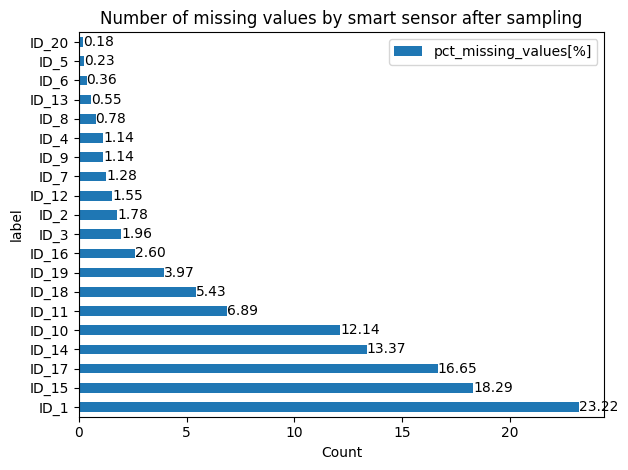

In [92]:
ax = (
    df_stats.sort_values(by="pct_missing_values[%]", ascending=False)
    .plot(kind="barh", 
          x="libelle", 
          y="pct_missing_values[%]", 
          xlabel="Count", 
          title="Number of missing values by smart sensor after sampling", 
          ylabel="label")
)

# Ajout des valeurs au bout des barres
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", label_type="edge")

plt.tight_layout()
plt.show()

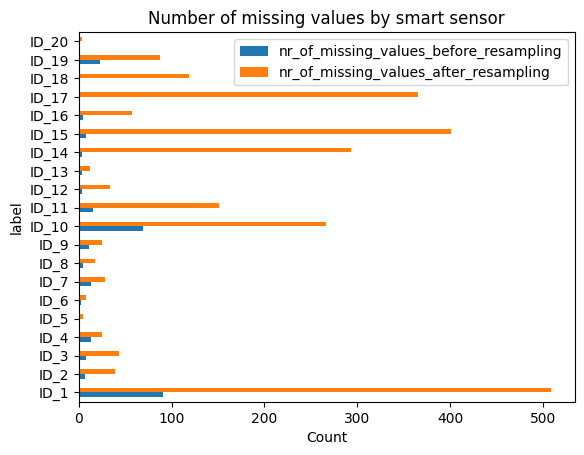

In [86]:
pd.DataFrame(data).plot(kind="barh", x="libelle", xlabel="Count", title="Number of missing values by smart sensor", ylabel="label");

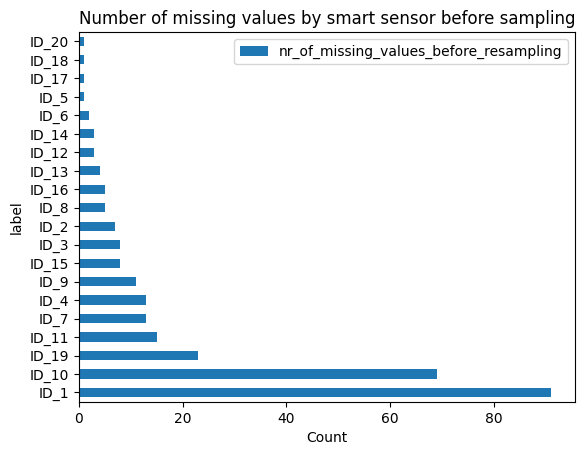

In [91]:
(
    pd.DataFrame(data).sort_values(by="nr_of_missing_values_before_resampling", ascending=False)
    .plot(kind="barh", x="libelle", y="nr_of_missing_values_before_resampling", xlabel="Count", title="Number of missing values by smart sensor before sampling", ylabel="label")

);

## EDA of Smart meters

Our analysis consists of the following steps: 

- handling missing values ;
- performing univariate and bivariate analysis;
- performing autocorrelation analysis;
- analyzing trends, seasonality and stationarity.

The smart meters 1 and 5 are analyzed in this notebook

### ID_5

In [11]:
# Extract ID_5 data
df_id_5 = df_filtered[df_filtered["libelle"] == "ID_5"]
df_id_5.sample(5)

,valeur_active,libelle
valeur_date,,
2024-05-02,28.0,ID_5
2022-12-05,28.0,ID_5
2022-09-18,28.0,ID_5
2022-11-06,27.0,ID_5
2022-11-20,28.0,ID_5


#### Resampling and handling missing values

In [12]:
df_id_5 = df_id_5.resample("D").first()

In [108]:
#Find the missing values
df_id_5[df_id_5[x].isna()]

,valeur_active,libelle,rolling_mean
valeur_date,,,


In [14]:
# Check values of the days before and after 2014-12-19
df_id_5.loc["2024-12-10":"2024-12-26"]

,valeur_active,libelle
valeur_date,,
2024-12-10,31.0,ID_5
2024-12-11,31.0,ID_5
2024-12-12,32.0,ID_5
2024-12-13,31.0,ID_5
2024-12-14,31.0,ID_5
2024-12-15,30.0,ID_5
2024-12-16,30.0,ID_5
2024-12-17,32.0,ID_5
2024-12-18,32.0,ID_5


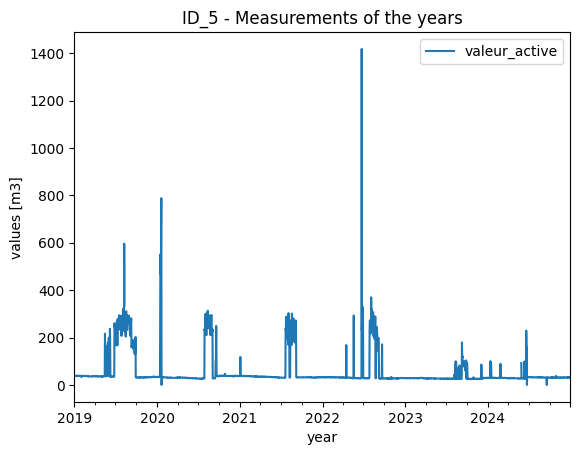

In [15]:
nr_id = "ID_5"
df_id_5.plot(
    xlabel="year", 
    ylabel="values [m3]",
    title=f"{nr_id} - Measurements of the years"
);

**Comment** : 
The visualization of our data shows the presence of seasonality. Water consumption varies very little from one day to the next within the same season (winter, summer, spring, autumn).

We will therefore use the backward-fill method, which replaces each NaN value with the value from the previous day.

In [109]:
df_id_5[x] = df_id_5[x].ffill()

#### Visualization

##### Univariate analysis

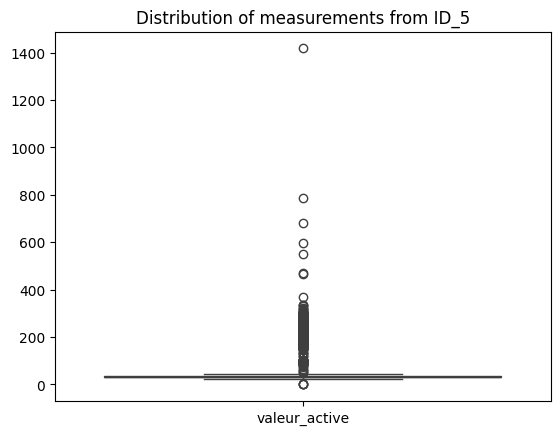

In [17]:
sns.boxplot(df_id_5)
plt.title(f"Distribution of measurements from {nr_id}");

**Comment** : 
- The distribution is skewed at right  

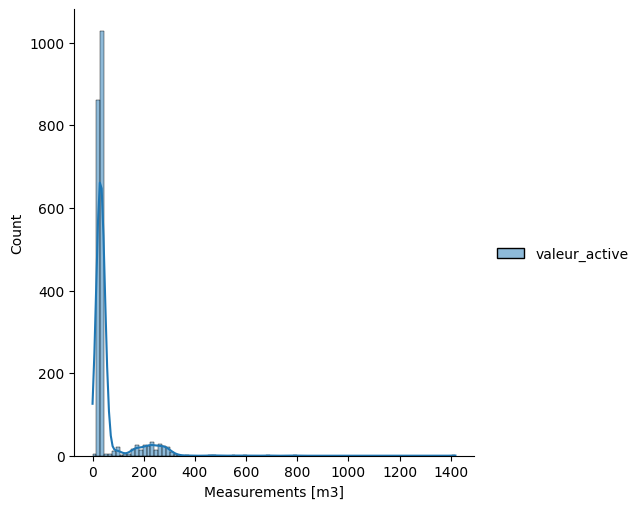

In [18]:
sns.displot(df_id_5, kde=True)
plt.xlabel("Measurements [m3]");

#### Bivariate analysis

##### Measurements by month

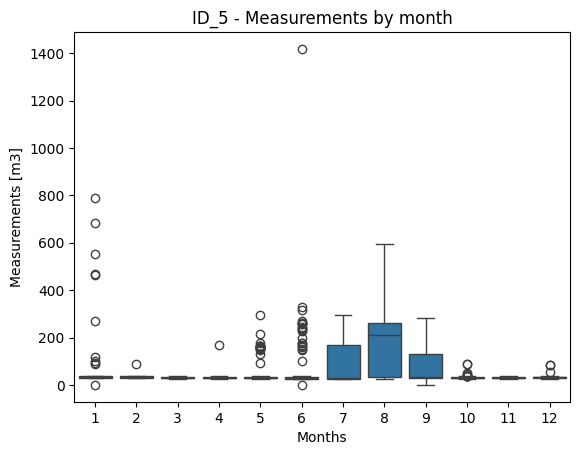

In [19]:
sns.boxplot(data=df_id_5, x=df_id_5.index.month, y="valeur_active")
plt.ylabel("Measurements [m3]")
plt.xlabel("Months")
plt.title(f"{nr_id} - Measurements by month");

##### Measurements by year

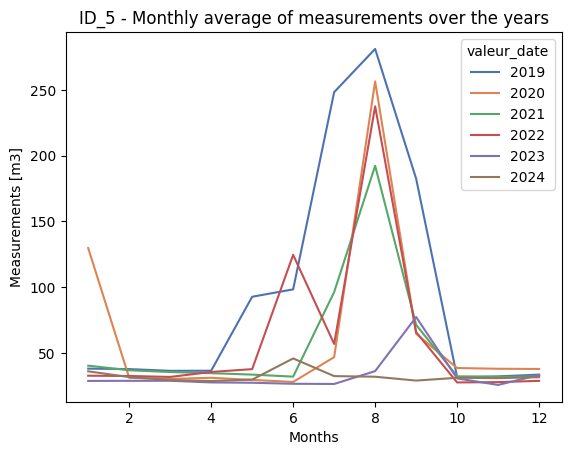

In [20]:
sns.lineplot(data=df_id_5, x=df_id_5.index.month, y="valeur_active", hue=df_id_5.index.year, palette="deep", errorbar=None)
plt.ylabel("Measurements [m3]")
plt.xlabel("Months")
plt.title(f"{nr_id} - Monthly average of measurements over the years");

##### Measurements by season

In [21]:
#defining function
def get_season(month):
  x = month%12 // 3 + 1
  if x == 1:
    season = "Winter"
  if x == 2:
    season = "Spring"
  if x == 3:
    season = "Summer"
  if x == 4:
    season = "Autumn"
  return season
    
seasons = [get_season(month) for month in df_id_5.index.month]

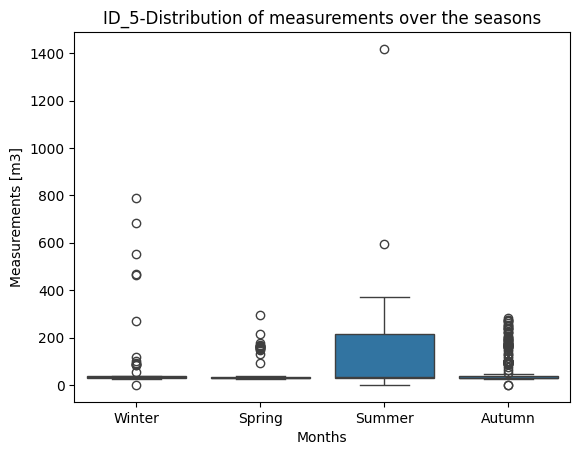

In [22]:
sns.boxplot(data=df_id_5, x=seasons, y="valeur_active")
plt.ylabel("Measurements [m3]")
plt.xlabel("Months")
plt.title(f"{nr_id}-Distribution of measurements over the seasons");

#### Autocorrelation

resource

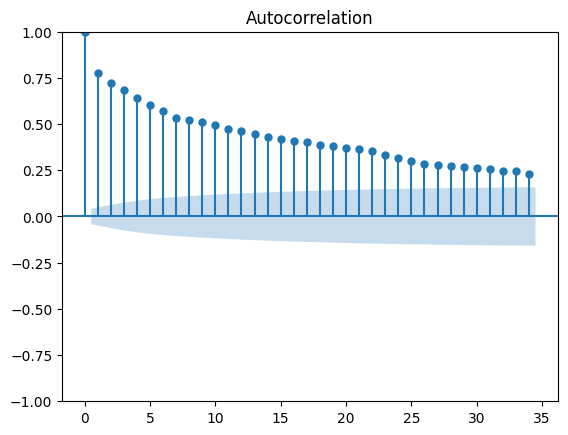

In [23]:
sm.graphics.tsa.plot_acf(df_id_5[["valeur_active"]]);

**Comment** : The ACF graph reveals that:
- our time series shows a positive correlation with its lags. There is therefore a trend
- approximately every 10 days, the quantity increases slightly before decreasing => This resembles seasonality.

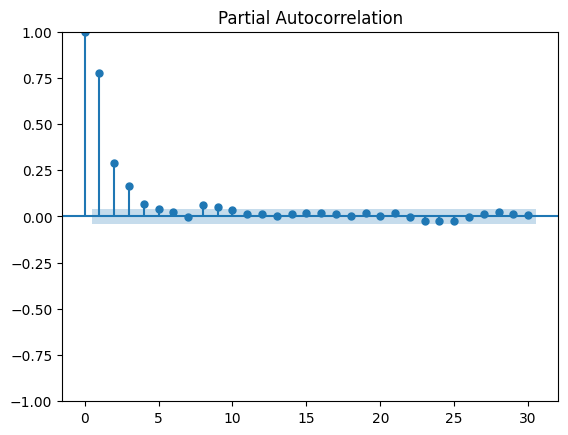

In [24]:
sm.graphics.tsa.plot_pacf(df_id_5[["valeur_active"]],lags=30);

**Comment** : The PACF graph reveals that:
- our time series shows a strong correlation with its lags 1, 2 and 3

#### Season decomposition

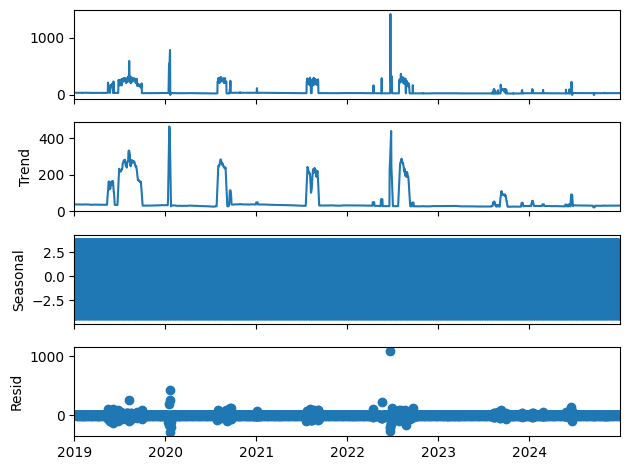

In [25]:
res = sm.tsa.seasonal_decompose(df_id_5[["valeur_active"]])
res.plot();

“Seasonal and Trend decomposition using Loess” (STL), while loess is a method for estimating nonlinear relationships.

"Flag indicating whether to use a weighted version that is robust to some forms of outliers."

Resources : 
- [link 1](https://medium.com/@kis.andras.nandor/demystifying-stl-understanding-seasonal-decomposition-of-time-series-d3c50150ec12)
- [link 2](https://www.statsmodels.org/dev/generated/statsmodels.tsa.seasonal.STL.html)
- [link 3](https://otexts.com/fpp3/stl.html)

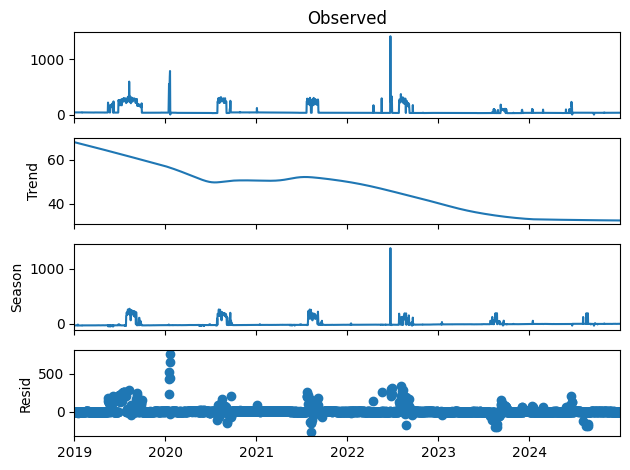

In [26]:
# Season decomposition over the days
res = sm.tsa.STL(df_id_5[["valeur_active"]], period=365, robust=True).fit()
res.plot();

**Comment** : Using a robust version for outliers, the residuals panel shows us certain outliers that may be caused by random variation or by a leak

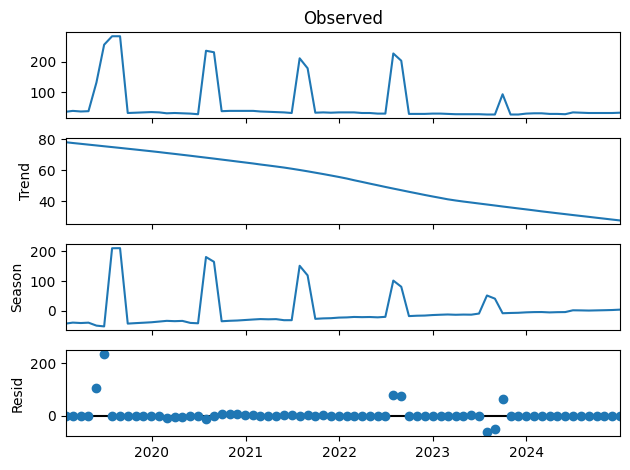

In [40]:
# Season decomposition over the month
res = sm.tsa.STL(df_id_5.resample('ME').ffill()[["valeur_active"]], period=12, robust=True).fit()
res.plot();

**Comment** : The residue panel allows anomalies to be identified month by month over all the years observed.
It also highlights a general downward trend. 

#### Stationarity

Resource:
- [adfuller](https://www.geeksforgeeks.org/python/how-to-check-if-time-series-data-is-stationary-with-python/)

- Ho (Null Hypothesis): The time series data is non-stationary
- H1 (alternate Hypothesis): The time series data is stationary

In [ ]:
result = sm.tsa.stattools.adfuller(df_id_5["valeur_active"])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

**Comment** : The test result is consistent.
The amount of water varies throughout the year, so the statistics (mean, standard deviation) cannot be identical.

# Feature Engineering


This function generates several time-series features from a given column.

**Parameters**
- df (pandas.DataFrame): DataFrame containing the target column. The index must be a datetime index.
- window (int): Window size used to compute rolling statistics and create lag features.
- col_name (str): Name of the column on which the transformations are applied.

**Features Created**
- Rolling mean: rolling_mean
- Rolling standard deviation: rolling_std
- Month extracted from the datetime index: month
- Day of the week extracted from the datetime index: dayofweek
- Lag features: lag_1 up to lag_window

**Returns** : Returns the enriched DataFrame with all generated features, dropping the libelle column.

## ID_5

In [126]:
## Rolling statistics (mean and std) over a window of 10 days and month

def extract_features(df, window, col_name=x):
    df["rolling_mean"] = df[col_name].rolling(window=window).mean()
    df["rolling_std"] = df[col_name].rolling(window=window).std()
    df["month"] = df.index.month
    df["dayofweek"] = df.index.dayofweek

    for i in range(1, window+1):
        df[f"lag_{i}"] = df[col_name].shift(i)
        
    return df.drop("libelle", axis=1)


In [129]:
X_id_5 = extract_features(df_id_5, window=10, col_name=x)
X_id_5.head(20)

,valeur_active,rolling_mean,rolling_std,month,dayofweek,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10
valeur_date,,,,,,,,,,,,,,,
2019-01-01,38.0,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-02,38.0,NaN,NaN,1,2,38.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-03,38.0,NaN,NaN,1,3,38.0,38.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-04,38.0,NaN,NaN,1,4,38.0,38.0,38.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-05,38.0,NaN,NaN,1,5,38.0,38.0,38.0,38.0,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-06,38.0,NaN,NaN,1,6,38.0,38.0,38.0,38.0,38.0,NaN,NaN,NaN,NaN,NaN
2019-01-07,38.0,NaN,NaN,1,0,38.0,38.0,38.0,38.0,38.0,38.0,NaN,NaN,NaN,NaN
2019-01-08,38.0,NaN,NaN,1,1,38.0,38.0,38.0,38.0,38.0,38.0,38.0,NaN,NaN,NaN
2019-01-09,38.0,NaN,NaN,1,2,38.0,38.0,38.0,38.0,38.0,38.0,38.0,38.0,NaN,NaN


# Export data

In [136]:
# drop NaN
X_id_5 = X_id_5.dropna()

In [141]:
filename = PATH + "5"
X_id_5.to_parquet(filename, index=True)